# Time Series and Trend Analysis

## Objective

The objective of this notebook is to analyze trends in the AI & Data Science Job Market dataset over time.

The analysis includes:

- Job posting trends by year
- Salary trends by year
- Experience trends over time
- Time-based business insights

The goal is to understand how the AI job market has evolved between 2020 and 2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df["average_salary"] = (
    df["salary_min_usd"] +
    df["salary_max_usd"]
) / 2

df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,average_salary
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large,64548.0
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium,70201.0
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large,162893.0
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium,69980.0
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large,115137.5


In [4]:
jobs_per_year = df["posted_year"].value_counts().sort_index()

jobs_per_year

posted_year
2020    7205
2021    7128
2022    7135
2023    7035
2024    7312
2025    7043
2026    7142
Name: count, dtype: int64

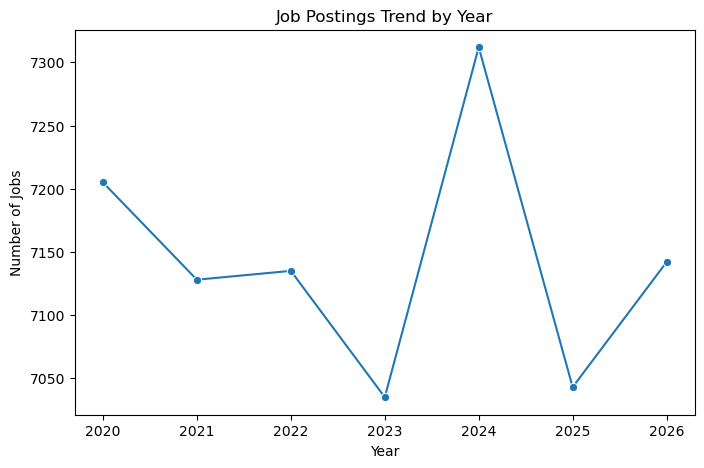

In [5]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=jobs_per_year.index,
    y=jobs_per_year.values,
    marker="o"
)

plt.title("Job Postings Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Jobs")

plt.show()

## Job Posting Trend

### Observation

The yearly distribution of job postings was analyzed to identify hiring trends over time.

The visualization shows how demand for AI and Data Science professionals changed across different years.

This helps understand market growth and recruitment patterns.

In [6]:
salary_trend = df.groupby("posted_year")["average_salary"].mean()

salary_trend

posted_year
2020    110757.182443
2021    111400.320356
2022    110873.484373
2023    111394.903554
2024    110348.491794
2025    110617.191183
2026    110681.480888
Name: average_salary, dtype: float64

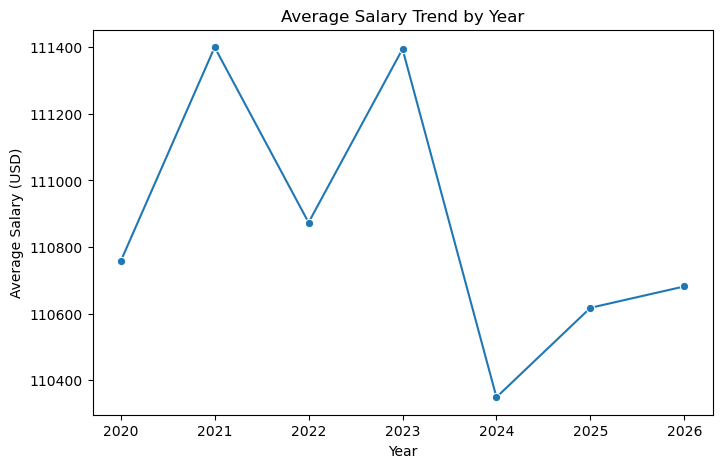

In [7]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=salary_trend.index,
    y=salary_trend.values,
    marker="o"
)

plt.title("Average Salary Trend by Year")
plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")

plt.show()

In [8]:
experience_trend = df.groupby("posted_year")["min_experience_years"].mean()

experience_trend

posted_year
2020    2.329077
2021    2.367424
2022    2.330343
2023    2.362900
2024    2.311543
2025    2.320318
2026    2.327779
Name: min_experience_years, dtype: float64

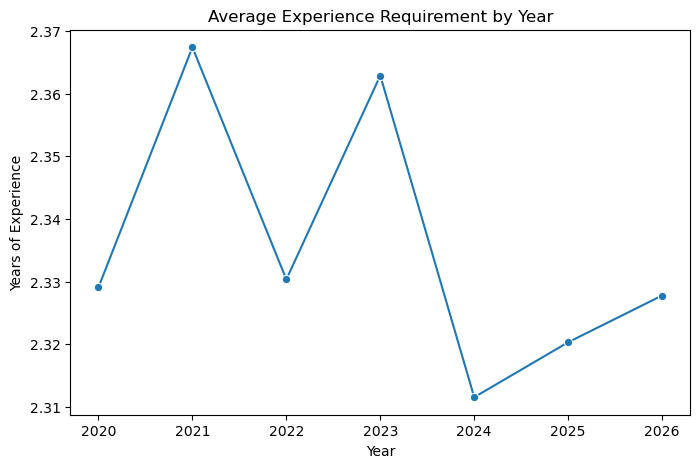

In [9]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=experience_trend.index,
    y=experience_trend.values,
    marker="o"
)

plt.title("Average Experience Requirement by Year")
plt.xlabel("Year")
plt.ylabel("Years of Experience")

plt.show()

In [10]:
year_summary = df.groupby("posted_year").agg({
    "job_id":"count",
    "average_salary":"mean",
    "min_experience_years":"mean"
})

year_summary.columns = [
    "total_jobs",
    "avg_salary",
    "avg_experience"
]

year_summary

,total_jobs,avg_salary,avg_experience
posted_year,,,
2020,7205,110757.182443,2.329077
2021,7128,111400.320356,2.367424
2022,7135,110873.484373,2.330343
2023,7035,111394.903554,2.362900
2024,7312,110348.491794,2.311543
2025,7043,110617.191183,2.320318
2026,7142,110681.480888,2.327779


## Time Series Analysis

### Observation

Time-based analysis was performed using the posting year.

The analysis focused on:

- Number of jobs posted each year
- Average salary trend
- Average experience requirement trend

These trends help identify changes in hiring demand, compensation, and skill expectations over time.

The yearly summary table provides an overall view of market evolution.

In [ ]:
## Business Insights

### Key Findings

1. The yearly job posting trend shows how demand for AI and Data Science professionals evolved over time.

2. The salary trend highlights whether compensation increased, decreased, or remained stable across years.

3. The experience trend reveals changes in employer expectations regarding candidate experience.

4. The yearly summary table combines hiring volume, salary levels, and experience requirements to provide a high-level view of market evolution.

### Business Value

These insights can help:

- Job seekers understand market trends.
- Companies benchmark compensation strategies.
- Recruiters identify hiring demand patterns.
- Educational institutions align training with industry needs.